# Punto 4 (1.2) — Transformación lineal a trozos

Nota: usa como entrada la imagen original en escala de grises. Asegúrate que las imágenes resultantes están en uint8 (rango 0-255).

In [1]:
# numpy: manejo de la imagen como matriz (recortes, reflexiones,
#        reordenar canales) y funciones auxiliares como np.zeros_like.
# matplotlib.pyplot: mostrar y guardar (savefig) las imágenes resultantes.
# PIL.Image: leer archivos de imagen (.png/.tif) y convertir entre modos
#            de color (RGB, L = escala de grises).
# cv2 (OpenCV): trae las funciones de transformación de intensidad ya
#      implementadas (gammaCorrection, logTransform, contrastStretching,
#      bitwise_not, inRange), en vez de escribir la fórmula a mano.
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2


## Imagen Original en Escala de Grises



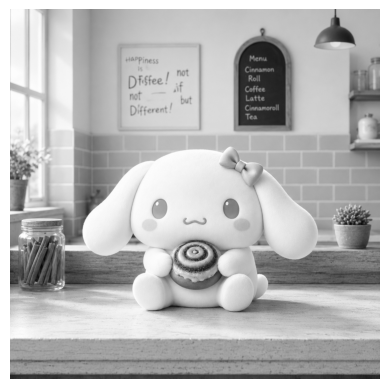

In [2]:
img = np.array(Image.open("../images/cinnamorroll_1024.png").convert("RGB"))
gray = np.array(Image.fromarray(img).convert("L"))

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_gris.png", bbox_inches="tight", pad_inches=0)


## T. Lineal a Trozos — r1=10 r2=50 s1=95 s2=145



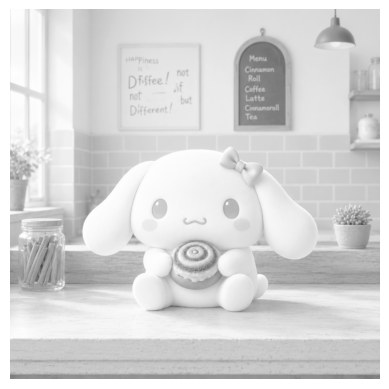

In [3]:
# cv2.intensity_transform.contrastStretching(input, output, r1, s1, r2, s2)
# arma internamente una tabla de búsqueda (LUT) con la recta a trozos que
# une (0,0) -> (r1,s1) -> (r2,s2) -> (255,255), y la aplica a toda la
# imagen de una vez. Rango de entrada bajo (10-50): casi ningún pixel
# cae ahí, el efecto principal aclara la imagen en general.
lineal_1 = np.zeros_like(gray)
cv2.intensity_transform.contrastStretching(gray, lineal_1, 10, 95, 50, 145)

plt.imshow(lineal_1, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_lineal_1.png", bbox_inches="tight", pad_inches=0)


## T. Lineal a Trozos — r1=60 r2=120 s1=95 s2=145



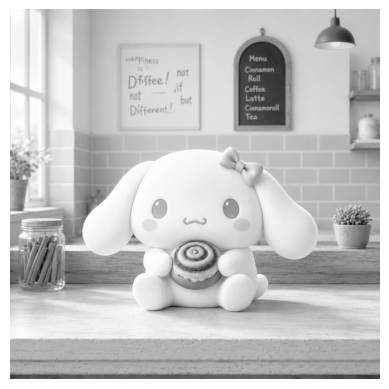

In [4]:
# Rango de entrada medio-bajo (60-120): cambio casi imperceptible porque
# pocos pixeles de esta imagen caen justo ahí.
lineal_2 = np.zeros_like(gray)
cv2.intensity_transform.contrastStretching(gray, lineal_2, 60, 95, 120, 145)

plt.imshow(lineal_2, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_lineal_2.png", bbox_inches="tight", pad_inches=0)


## T. Lineal a Trozos — r1=150 r2=200 s1=95 s2=145



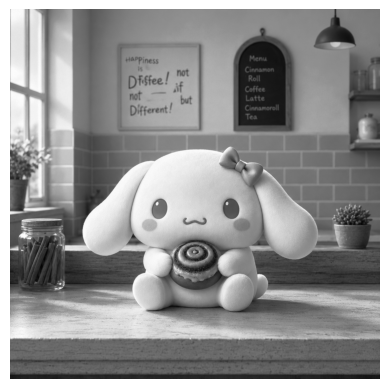

In [5]:
# Rango de entrada 150-200: coincide con donde se concentra buena parte
# del histograma de esta imagen, así que el cambio es notorio.
lineal_3 = np.zeros_like(gray)
cv2.intensity_transform.contrastStretching(gray, lineal_3, 150, 95, 200, 145)

plt.imshow(lineal_3, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_lineal_3.png", bbox_inches="tight", pad_inches=0)
